# Phase 2: Uplift Modeling

Goal: estimate heterogeneous treatment effects at the user level.

In Phase 1, we validated that the experiment is randomized and balanced. In Phase 2, we move from average treatment effect to conditional treatment effect:

`uplift(x) = P(conversion | treatment=1, X=x) - P(conversion | treatment=0, X=x)`

Business translation: which users are more likely to convert because we treat them?

## 1. Setup

This first version uses scikit-learn models so the notebook runs with the current project dependencies. Later, we can swap the base model to LightGBM for stronger performance.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

In [2]:
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "criteo-uplift-v2.1.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "uplift_scores_sample.parquet"

assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/roder/OneDrive/Desktop/Causal Project/causal-impact-estimation/data/raw/criteo-uplift-v2.1.csv')

## 2. Load a Modeling Sample

The full dataset has nearly 14 million rows. For learning and iteration, we start with a balanced modeling sample.

Why balanced? The original experiment has many more treated users than control users. For first-pass S- and T-learners, a balanced sample makes training faster and easier to reason about. Later, we can train on larger data and use proper weighting.

In [3]:
con = duckdb.connect(database=":memory:")

con.execute(f"""
    create or replace view experiment as
    select *
    from read_csv_auto('{DATA_PATH.as_posix()}', sample_size=100000)
""")

con.sql("select count(*) as users from experiment").df()

,users
0,13979592


In [25]:
N_PER_GROUP = 250_000

model_df = con.sql(f"""
    with control_sample as (
        select *
        from (select * from experiment where treatment = 0)
        using sample {N_PER_GROUP} rows
    ),
    treatment_sample as (
        select *
        from (select * from experiment where treatment = 1)
        using sample {N_PER_GROUP} rows
    )
    select * from control_sample
    union all
    select * from treatment_sample
""").df()

model_df.shape

(500000, 16)

In [29]:
model_df.groupby("treatment").agg(
    users=("conversion", "size"),
    conversion_rate=("conversion", "mean"),
    visit_rate=("visit", "mean"),
    exposure_rate=("exposure", "mean"),
)

,users,conversion_rate,visit_rate,exposure_rate
treatment,,,,
0,250000,0.0019,0.0385,0.0000
1,250000,0.0029,0.0482,0.0358


## 3. Train/Test Split

We split by rows while stratifying on treatment and conversion. This keeps treatment/outcome mix similar across train and test.

In [30]:
feature_cols = [c for c in model_df.columns if c.startswith("f")]
target_col = "conversion"
treatment_col = "treatment"

model_df["strata"] = model_df[treatment_col].astype(str) + "_" + model_df[target_col].astype(str)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=model_df["strata"],
)

train_df = train_df.drop(columns="strata")
test_df = test_df.drop(columns="strata")

train_df.shape, test_df.shape

((350000, 16), (150000, 16))

In [31]:
train_df.groupby(treatment_col)[target_col].agg(["size", "mean"]), test_df.groupby(treatment_col)[target_col].agg(["size", "mean"])

(             size   mean
 treatment               
 0          175000 0.0019
 1          175000 0.0029,
             size   mean
 treatment              
 0          75000 0.0019
 1          75000 0.0029)

## 4. Helper: Model Diagnostics

AUC/average precision are not uplift metrics. They only tell us whether each response model predicts conversion reasonably. Phase 3 will evaluate uplift ranking directly with Qini/AUUC.

In [32]:
def evaluate_response_model(y_true, y_score, label):
    return {
        "model": label,
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "mean_predicted_conversion": y_score.mean(),
        "actual_conversion_rate": y_true.mean(),
    }


def make_base_model():
    return HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    )

## 5. S-Learner

S-learner = single model.

Train one conversion model using both user features and treatment assignment:

`conversion ~ features + treatment`

Then score every test user twice:

- once pretending `treatment = 1`
- once pretending `treatment = 0`

The difference is predicted uplift.

In [33]:
s_features = feature_cols + [treatment_col]

s_model = make_base_model()
s_model.fit(train_df[s_features], train_df[target_col])
s_test_pred = s_model.predict_proba(test_df[s_features])[:, 1]
evaluate_response_model(test_df[target_col], s_test_pred, "S-learner response model")

{'model': 'S-learner response model',
 'roc_auc': 0.9379269072932006,
 'average_precision': 0.12966129083600839,
 'mean_predicted_conversion': np.float64(0.002497258329479942),
 'actual_conversion_rate': np.float64(0.0023933333333333333)}

In [34]:
test_s_treated = test_df[feature_cols].copy()
test_s_treated[treatment_col] = 1

test_s_control = test_df[feature_cols].copy()
test_s_control[treatment_col] = 0

test_df = test_df.copy()
test_df["s_pred_treated"] = s_model.predict_proba(test_s_treated[s_features])[:, 1]
test_df["s_pred_control"] = s_model.predict_proba(test_s_control[s_features])[:, 1]
test_df["s_uplift"] = test_df["s_pred_treated"] - test_df["s_pred_control"]

test_df[["s_pred_treated", "s_pred_control", "s_uplift"]].describe()

,s_pred_treated,s_pred_control,s_uplift
count,"150,000.0000","150,000.0000","150,000.0000"
mean,0.0028,0.0021,0.0007
std,0.0282,0.0240,0.0111
min,0.0001,0.0001,-0.2354
25%,0.0001,0.0001,0.0000
50%,0.0002,0.0002,0.0000
75%,0.0005,0.0005,0.0000
max,0.9999,1.0000,0.5611


## 6. T-Learner

T-learner = two models.

Train one model on treated users and one model on control users:

- treated model estimates `P(conversion | treatment=1, X)`
- control model estimates `P(conversion | treatment=0, X)`

Then uplift is the difference between those two predictions.

In [35]:
treated_train = train_df[train_df[treatment_col] == 1]
control_train = train_df[train_df[treatment_col] == 0]

t_model_treated = make_base_model()
t_model_control = make_base_model()

t_model_treated.fit(treated_train[feature_cols], treated_train[target_col])
t_model_control.fit(control_train[feature_cols], control_train[target_col])

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.06
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",150
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.01
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing v

In [36]:
treated_test = test_df[test_df[treatment_col] == 1]
control_test = test_df[test_df[treatment_col] == 0]

diagnostics = []
diagnostics.append(evaluate_response_model(
    treated_test[target_col],
    t_model_treated.predict_proba(treated_test[feature_cols])[:, 1],
    "T-learner treated outcome model",
))
diagnostics.append(evaluate_response_model(
    control_test[target_col],
    t_model_control.predict_proba(control_test[feature_cols])[:, 1],
    "T-learner control outcome model",
))

pd.DataFrame(diagnostics)

,model,roc_auc,average_precision,mean_predicted_conversion,actual_conversion_rate
0,T-learner treated outcome model,0.9439,0.1344,0.0031,0.0029
1,T-learner control outcome model,0.8772,0.0919,0.0025,0.0019


In [37]:
test_df["t_pred_treated"] = t_model_treated.predict_proba(test_df[feature_cols])[:, 1]
test_df["t_pred_control"] = t_model_control.predict_proba(test_df[feature_cols])[:, 1]
test_df["t_uplift"] = test_df["t_pred_treated"] - test_df["t_pred_control"]

test_df[["t_pred_treated", "t_pred_control", "t_uplift"]].describe()

,t_pred_treated,t_pred_control,t_uplift
count,"150,000.0000","150,000.0000","150,000.0000"
mean,0.0029,0.0027,0.0002
std,0.0299,0.0269,0.0305
min,0.0001,0.0000,-0.9977
25%,0.0001,0.0011,-0.0010
50%,0.0001,0.0011,-0.0010
75%,0.0004,0.0013,-0.0008
max,0.9789,1.0000,0.9789


## 7. Compare Uplift Scores

At this stage, we inspect whether the learners produce reasonable score distributions. We are not claiming the best policy yet. That comes in Phase 3 with Qini/AUUC.

In [38]:
uplift_summary = test_df[["s_uplift", "t_uplift"]].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
uplift_summary

,s_uplift,t_uplift
count,"150,000.0000","150,000.0000"
mean,0.0007,0.0002
std,0.0111,0.0305
min,-0.2354,-0.9977
1%,-0.0007,-0.0021
5%,-0.0000,-0.0010
10%,-0.0000,-0.0010
25%,0.0000,-0.0010
50%,0.0000,-0.0010
75%,0.0000,-0.0008


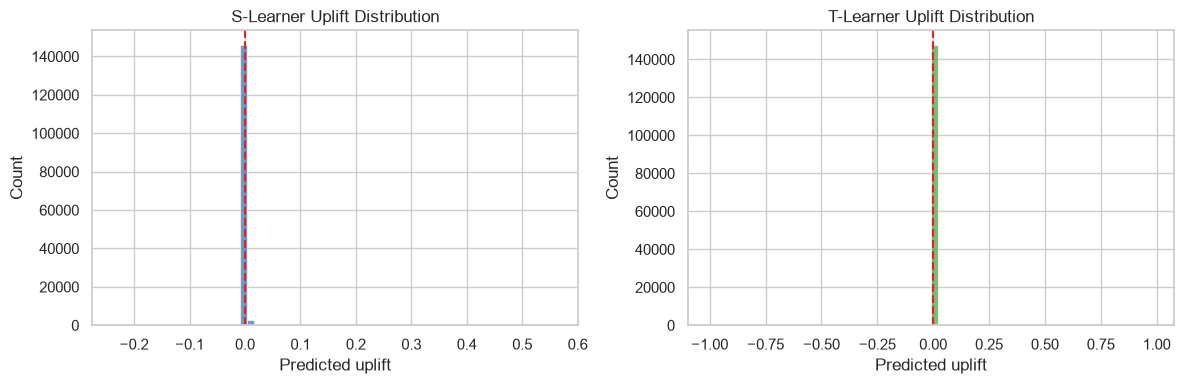

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(test_df["s_uplift"], bins=60, ax=axes[0], color="#4C78A8")
axes[0].axvline(0, color="#D62728", linestyle="--")
axes[0].set_title("S-Learner Uplift Distribution")
axes[0].set_xlabel("Predicted uplift")

sns.histplot(test_df["t_uplift"], bins=60, ax=axes[1], color="#59A14F")
axes[1].axvline(0, color="#D62728", linestyle="--")
axes[1].set_title("T-Learner Uplift Distribution")
axes[1].set_xlabel("Predicted uplift")

plt.tight_layout()

In [40]:
test_df[["s_uplift", "t_uplift"]].corr()

,s_uplift,t_uplift
s_uplift,1.0000,0.1856
t_uplift,0.1856,1.0000


## 8. Uplift Deciles

This is an early sanity check: users ranked high by predicted uplift should have stronger observed treatment-control lift than users ranked low.

This is not a perfect causal evaluation because each decile still contains observed treated/control users, but it is a useful bridge to Qini/AUUC.

In [41]:
def decile_lift_table(df, score_col):
    scored = df.copy()
    scored["uplift_decile"] = pd.qcut(
        scored[score_col].rank(method="first"),
        q=10,
        labels=False,
    ) + 1
    scored["uplift_decile"] = 11 - scored["uplift_decile"]

    table = (
        scored.groupby(["uplift_decile", treatment_col])[target_col]
        .agg(users="size", conversion_rate="mean")
        .reset_index()
        .pivot(index="uplift_decile", columns=treatment_col, values=["users", "conversion_rate"])
    )
    table.columns = [f"{metric}_{'control' if treatment == 0 else 'treatment'}" for metric, treatment in table.columns]
    table = table.reset_index()
    table["observed_lift"] = table["conversion_rate_treatment"] - table["conversion_rate_control"]
    return table.sort_values("uplift_decile")


s_deciles = decile_lift_table(test_df, "s_uplift")
t_deciles = decile_lift_table(test_df, "t_uplift")

s_deciles

,uplift_decile,users_control,users_treatment,conversion_rate_control,conversion_rate_treatment,observed_lift
0,1,"7,128.0000","7,872.0000",0.0112,0.0188,0.0076
1,2,"7,602.0000","7,398.0000",0.0011,0.0018,0.0007
2,3,"7,585.0000","7,415.0000",0.0003,0.0001,-0.0001
3,4,"7,591.0000","7,409.0000",0.0005,0.0003,-0.0003
4,5,"7,655.0000","7,345.0000",0.0003,0.0001,-0.0001
5,6,"7,384.0000","7,616.0000",0.0000,0.0000,0.0000
6,7,"7,546.0000","7,454.0000",0.0004,0.0000,-0.0004
7,8,"7,417.0000","7,583.0000",0.0003,0.0003,-0.0000
8,9,"7,565.0000","7,435.0000",0.0001,0.0005,0.0004
9,10,"7,527.0000","7,473.0000",0.0056,0.0059,0.0003


In [42]:
t_deciles

,uplift_decile,users_control,users_treatment,conversion_rate_control,conversion_rate_treatment,observed_lift
0,1,"7,104.0000","7,896.0000",0.0096,0.0175,0.0079
1,2,"7,655.0000","7,345.0000",0.0014,0.0020,0.0006
2,3,"7,481.0000","7,519.0000",0.0001,0.0005,0.0004
3,4,"7,600.0000","7,400.0000",0.0009,0.0003,-0.0007
4,5,"7,624.0000","7,376.0000",0.0007,0.0005,-0.0001
5,6,"7,547.0000","7,453.0000",0.0000,0.0001,0.0001
6,7,"7,605.0000","7,395.0000",0.0004,0.0000,-0.0004
7,8,"7,512.0000","7,488.0000",0.0003,0.0000,-0.0003
8,9,"7,474.0000","7,526.0000",0.0001,0.0000,-0.0001
9,10,"7,398.0000","7,602.0000",0.0062,0.0067,0.0005


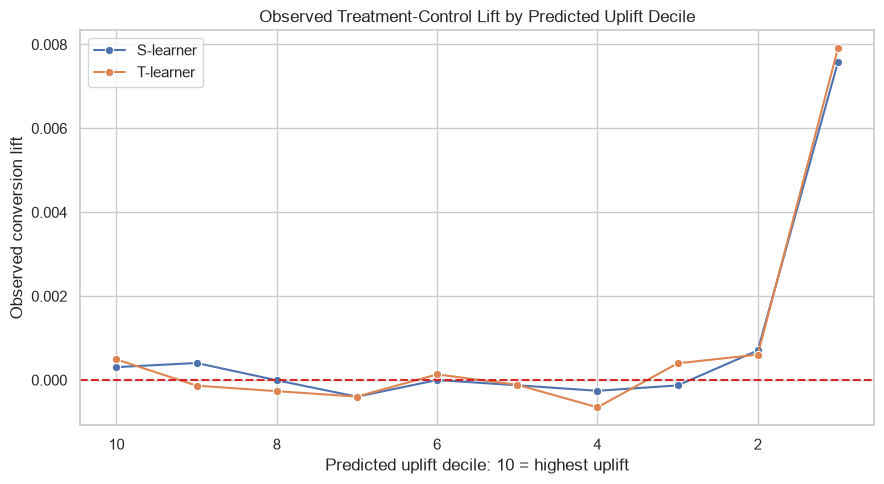

In [43]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=s_deciles, x="uplift_decile", y="observed_lift", marker="o", label="S-learner")
sns.lineplot(data=t_deciles, x="uplift_decile", y="observed_lift", marker="o", label="T-learner")
plt.axhline(0, color="#D62728", linestyle="--")
plt.gca().invert_xaxis()
plt.title("Observed Treatment-Control Lift by Predicted Uplift Decile")
plt.xlabel("Predicted uplift decile: 10 = highest uplift")
plt.ylabel("Observed conversion lift")
plt.legend()
plt.tight_layout()

## 9. Save Scored Test Set

Save the test set with uplift scores so Phase 3 can evaluate targeting policies using Qini/AUUC and cumulative gain.

In [ ]:
score_cols = [
    treatment_col,
    target_col,
    "visit",
    "exposure",
    *feature_cols,
    "s_pred_treated",
    "s_pred_control",
    "s_uplift",
    "t_pred_treated",
    "t_pred_control",
    "t_uplift",
]

test_df[score_cols].to_parquet(OUTPUT_PATH, index=False)
OUTPUT_PATH

WindowsPath('c:/Users/roder/OneDrive/Desktop/Causal Project/causal-impact-estimation/data/processed/uplift_scores_sample.parquet')

## 10. Phase 2 Readout

- The S-learner estimated uplift by training one conversion model with treatment assignment included as a feature.
- The T-learner estimated uplift by training separate treated and control outcome models, then subtracting predicted control conversion probability from predicted treated conversion probability.
- The uplift distributions were highly concentrated near zero, which is expected because the absolute treatment effect is small and conversion is rare.
- Both learners produced some extreme individual uplift predictions, suggesting probability instability and possible overfitting in the first-pass tree-based models.
- The T-learner showed some separation in higher uplift deciles, but the decile results were noisy and should not be treated as final policy evidence.
- Phase 3 should evaluate targeting performance using Qini, AUUC, and cumulative gain curves before choosing a targeting policy.

Important caveat: response-model AUC is not the same as uplift quality. A model can predict conversion well but still be poor at ranking incremental impact.